In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
BASE_DIR = Path("..")

FRACTURE_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_fracture_index.csv"

df = pd.read_csv(FRACTURE_DATA_PATH)

df.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date,primary_category,reality_fracture_score,control_loss_score,body_boundary_score,nonhuman_presence_score,liminal_space_score,ritual_logic_score,domestic_corruption_score,residual_impact_score,reality_fracture_normalized,control_loss_normalized,body_boundary_normalized,nonhuman_presence_normalized,liminal_space_normalized,ritual_logic_normalized,domestic_corruption_normalized,residual_impact_normalized,horror_fracture_index,dominant_fracture,horror_fracture_index_per_1000,high_rating
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19493,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20,Drugs and Addictions,34,15,39,10,23,1,16,37,0.009551,0.004213,0.010955,0.002809,0.006461,0.000281,0.004494,0.010393,0.006145,body_boundary,6.144663,1
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,9.13,20837,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22,Madness,30,11,27,31,31,0,26,50,0.007655,0.002807,0.006890,0.007910,0.007910,0.000000,0.006634,0.012758,0.006571,residual_impact,6.570554,1
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10859,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10,Abductions and Kidnappings,10,11,21,15,19,1,37,23,0.004684,0.005152,0.009836,0.007026,0.008899,0.000468,0.017330,0.010773,0.008021,domestic_corruption,8.021077,1
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4150,768,Ashley Rose Wellman,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",3 minutes,2019-07-13,Beings and Entities,3,4,2,15,2

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3478
Columns: 32
<class 'pandas.DataFrame'>
RangeIndex: 3478 entries, 0 to 3477
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   title                           3478 non-null   str    
 1   story_text                      3478 non-null   str    
 2   text_lower                      3478 non-null   str    
 3   rating                          3478 non-null   float64
 4   rating_numeric                  3478 non-null   float64
 5   story_length_chars              3478 non-null   int64  
 6   word_count                      3478 non-null   int64  
 7   tags                            3478 non-null   str    
 8   categories                      3478 non-null   str    
 9   estimated_reading_time          3478 non-null   str    
 10  publish_date                    3478 non-null   str    
 11  primary_category                3478 non-null   str    
 12  reality_fracture_score

In [4]:
df["high_rating"].value_counts(normalize=True)

high_rating
0    0.748131
1    0.251869
Name: proportion, dtype: float64

In [5]:
feature_columns = [
    "word_count",
    "story_length_chars",
    "reality_fracture_normalized",
    "control_loss_normalized",
    "body_boundary_normalized",
    "nonhuman_presence_normalized",
    "liminal_space_normalized",
    "ritual_logic_normalized",
    "domestic_corruption_normalized",
    "residual_impact_normalized",
    "horror_fracture_index_per_1000"
]

target_column = "high_rating"

X = df[feature_columns]
y = df[target_column]

X.head()

,word_count,story_length_chars,reality_fracture_normalized,control_loss_normalized,body_boundary_normalized,nonhuman_presence_normalized,liminal_space_normalized,ritual_logic_normalized,domestic_corruption_normalized,residual_impact_normalized,horror_fracture_index_per_1000
0,3560,19493,0.009551,0.004213,0.010955,0.002809,0.006461,0.000281,0.004494,0.010393,6.144663
1,3919,20837,0.007655,0.002807,0.006890,0.007910,0.007910,0.000000,0.006634,0.012758,6.570554
2,2135,10859,0.004684,0.005152,0.009836,0.007026,0.008899,0.000468,0.017330,0.010773,8.021077
3,768,4150,0.003906,0.005208,0.002604,0.019531,0.002604,0.001302,0.005208,0.016927,7.161458
4,6021,32767,0.004152,0.004152,0.006643,0.007806,0.007806,0.000997,0.003986,0.010463,5.750706


In [6]:
X.isnull().sum()

word_count                        0
story_length_chars                0
reality_fracture_normalized       0
control_loss_normalized           0
body_boundary_normalized          0
nonhuman_presence_normalized      0
liminal_space_normalized          0
ritual_logic_normalized           0
domestic_corruption_normalized    0
residual_impact_normalized        0
horror_fracture_index_per_1000    0
dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2782, 11)
Test size: (696, 11)


In [8]:
baseline_prediction = y_train.mode()[0]

baseline_accuracy = (y_test == baseline_prediction).mean()

print("Baseline prediction:", baseline_prediction)
print("Baseline accuracy:", baseline_accuracy)

Baseline prediction: 0
Baseline accuracy: 0.7485632183908046


In [9]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1-score:", f1_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
Accuracy: 0.7442528735632183
Precision: 0.47619047619047616
Recall: 0.17142857142857143
F1-score: 0.25210084033613445

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       521
           1       0.48      0.17      0.25       175

    accuracy                           0.74       696
   macro avg       0.62      0.55      0.55       696
weighted avg       0.70      0.74      0.70       696



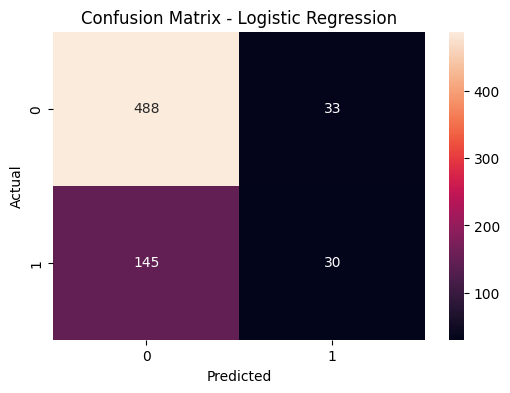

In [10]:
conf_matrix = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7413793103448276
Precision: 0.45901639344262296
Recall: 0.16
F1-score: 0.23728813559322035

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.84       521
           1       0.46      0.16      0.24       175

    accuracy                           0.74       696
   macro avg       0.61      0.55      0.54       696
weighted avg       0.69      0.74      0.69       696



In [14]:
model_comparison = pd.DataFrame({
    "model": ["Baseline", "Logistic Regression", "Random Forest"],
    "accuracy": [
        baseline_accuracy,
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "precision": [
        np.nan,
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "recall": [
        np.nan,
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "f1_score": [
        np.nan,
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,model,accuracy,precision,recall,f1_score
0,Baseline,0.748563,NaN,NaN,NaN
1,Logistic Regression,0.744253,0.476190,0.171429,0.252101
2,Random Forest,0.741379,0.459016,0.160000,0.237288


Model Interpretation

The baseline model achieved an accuracy of approximately 0.75 by always predicting the majority class. Both Logistic Regression and Random Forest produced slightly lower accuracy than the baseline.

This means that the current features are not strong enough to reliably predict whether a creepypasta will be in the top 25% of ratings.

However, this does not invalidate the project. The goal of this project is not only prediction. The main value is interpretability: the Horror Fracture Index translates horror narratives into measurable psychological and narrative signals.

The low recall for high-rated stories suggests that audience reception depends on additional factors not captured by the current features, such as writing quality, originality, pacing, emoti

In [12]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,word_count,0.126443
1,story_length_chars,0.113028
8,domestic_corruption_normalized,0.092388
9,residual_impact_normalized,0.089006
3,control_loss_normalized,0.088667
5,nonhuman_presence_normalized,0.086465
6,liminal_space_normalized,0.085254
4,body_boundary_normalized,0.085126
2,reality_fracture_normalized,0.082224
10,horror_fracture_index_per_1000,0.080247


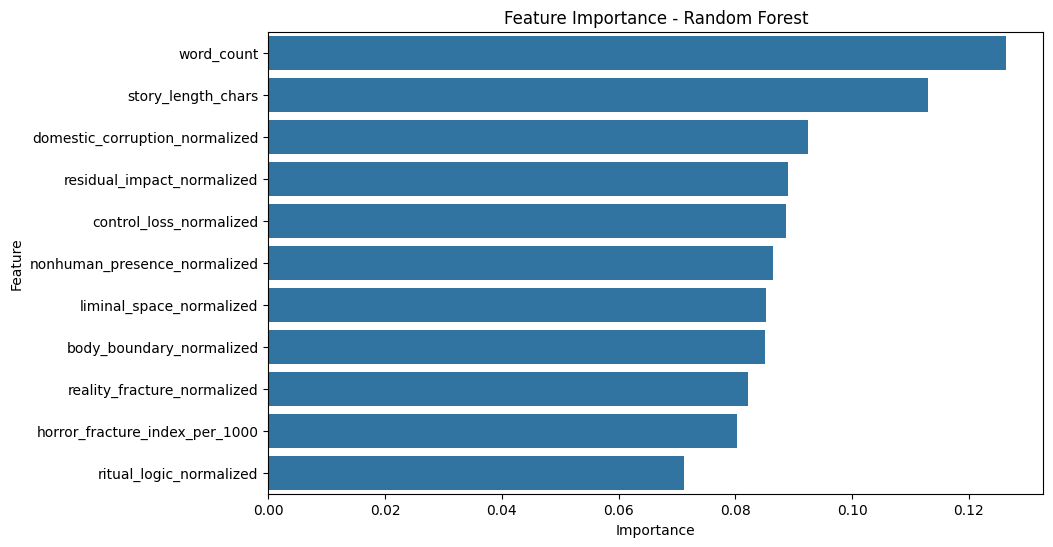

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Modeling Conclusions

This notebook tested whether basic length features and Horror Fracture Index features can help distinguish high-rated creepypasta stories.

The model results show that neither Logistic Regression nor Random Forest outperformed the baseline accuracy. This suggests that high audience reception is not explained only by story length or the current fracture features.

The most important variables in the Random Forest model were story length features and several narrative fracture dimensions, especially domestic corruption, residual impact, and control loss.

The most important part of this project is not predictive accuracy alone. The main contribution is the creation of an interpretable feature system that translates horror narratives into measurable psychological and narrative dimensions.

These results suggest that a content platform could use fracture-based features as descriptive or recommendation metadata, rather than relying on them as a standalone predictor of ratings.

Modeling Conclusions

This notebook tested whether basic length features and Horror Fracture Index features can help distinguish high-rated creepypasta stories.

The goal was not to build a perfect prediction model. Instead, the model was used as an analytical tool to evaluate whether the custom narrative fracture variables contain useful signals about audience reception.

The results should be compared against the baseline accuracy. If the model only slightly improves over the baseline, this suggests that rating is influenced by factors beyond the current features, such as writing quality, pacing, originality, community familiarity, author reputation, or emotional payoff.

The most important part of this project is not the predictive accuracy alone. The main contribution is the creation of an interpretable feature system that translates horror narratives into measurable psychological and narrative dimensions.